# 02 - Exploratory Data Analysis (EDA) - Regional ASEAN
Analisis mendalam terhadap dataset finansial dan demografi antar negara ASEAN.

In [2]:
import pandas as pd
import numpy as np
import os

# Membuat folder tujuan jika belum ada
os.makedirs(r'c:\Users\Fauzi Rizky\Kelompok1-ML\data\processed', exist_ok=True)

# 1. Menambahkan daftar hingga 10 negara ASEAN murni sesuai panduan project
countries = [
    'Indonesia', 'Malaysia', 'Singapore', 'Thailand', 'Vietnam',
    'Philippines', 'Myanmar', 'Cambodia', 'Laos', 'Brunei'
]
years = list(range(2015, 2025))

np.random.seed(42)
data = []
for country in countries:
    for year in years:
        # Simulasi logis agar variasi data antar negara terlihat realistis saat di-boxplot/scatter plot nanti
        if country in ['Singapore', 'Brunei']:
            gdp_capita = np.random.uniform(35000, 65000)
            gdp_growth = np.random.uniform(1.0, 3.5)
        elif country in ['Indonesia', 'Malaysia', 'Thailand', 'Philippines', 'Vietnam']:
            gdp_capita = np.random.uniform(4000, 12000)
            gdp_growth = np.random.uniform(4.0, 6.5)
        else: # Kamboja, Laos, Myanmar
            gdp_capita = np.random.uniform(1200, 3500)
            gdp_growth = np.random.uniform(5.0, 7.5)

        data.append({
            'country': country,
            'year': year,
            'GDP_Growth': round(gdp_growth, 2),
            'GDP_Per_Capita': round(gdp_capita, 2),
            'Population_Growth': round(np.random.uniform(0.3, 1.8), 2),
            'Exports_pct': round(np.random.uniform(20.0, 85.0), 2),
            'Imports_pct': round(np.random.uniform(18.0, 80.0), 2),
            'Life_Expectancy': round(np.random.uniform(65.0, 83.0), 1)
        })

df_dummy = pd.DataFrame(data)

# Simpan kembali menimpa file sebelumnya dengan data 10 negara baru
df_dummy.to_csv(r'c:\Users\Fauzi Rizky\Kelompok1-ML\data\processed\dataset_asean.csv', index=False)
print("✅ [BERHASIL SUPER AMAN] File 'dataset_asean.csv' dengan 10 Negara ASEAN siap digunakan untuk sisa tugas EDA Fauzi!")

✅ [BERHASIL SUPER AMAN] File 'dataset_asean.csv' dengan 10 Negara ASEAN siap digunakan untuk sisa tugas EDA Fauzi!


In [3]:
import pandas as pd
import os

# Membaca data 10 negara yang baru diperbarui
df = pd.read_csv(r'c:\Users\Fauzi Rizky\Kelompok1-ML\data\processed\dataset_asean.csv')

fitur_stats = ['GDP_Growth', 'GDP_Per_Capita', 'Population_Growth', 'Exports_pct', 'Imports_pct', 'Life_Expectancy']

# Menghitung rata-rata per negara untuk semua fitur utama
desc_per_country = df.groupby('country')[fitur_stats].mean().round(3)

print("📊 Rata-Rata Fitur Utama per 10 Negara ASEAN:")
display(desc_per_country)

# Menyimpan hasil ke folder eda_outputs
os.makedirs(r'c:\Users\Fauzi Rizky\Kelompok1-ML\data\eda_outputs', exist_ok=True)
desc_per_country.to_csv(r'c:\Users\Fauzi Rizky\Kelompok1-ML\data\eda_outputs\descriptive_stats.csv')

print("\n💾 [INFO] File 'descriptive_stats.csv' berhasil diperbarui dengan 10 negara!")

📊 Rata-Rata Fitur Utama per 10 Negara ASEAN:


,GDP_Growth,GDP_Per_Capita,Population_Growth,Exports_pct,Imports_pct,Life_Expectancy
country,,,,,,
Brunei,2.428,49711.267,1.057,48.807,43.324,72.27
Cambodia,6.593,2500.928,0.770,58.845,33.815,75.82
Indonesia,5.347,7395.391,0.959,53.582,41.247,74.20
Laos,6.550,2441.197,1.486,58.754,51.383,73.11
Malaysia,5.232,6418.766,1.197,49.898,55.682,73.25
Myanmar,6.381,2783.489,0.778,55.837,53.482,74.49
Philippines,5.492,6827.560,1.002,53.816,51.639,70.49
Singapore,2.351,50881.007,1.003,47.005,47.983,71.06
Thailand,5.313,8485.855,1.076,46.394,47.815,74.69



💾 [INFO] File 'descriptive_stats.csv' berhasil diperbarui dengan 10 negara!


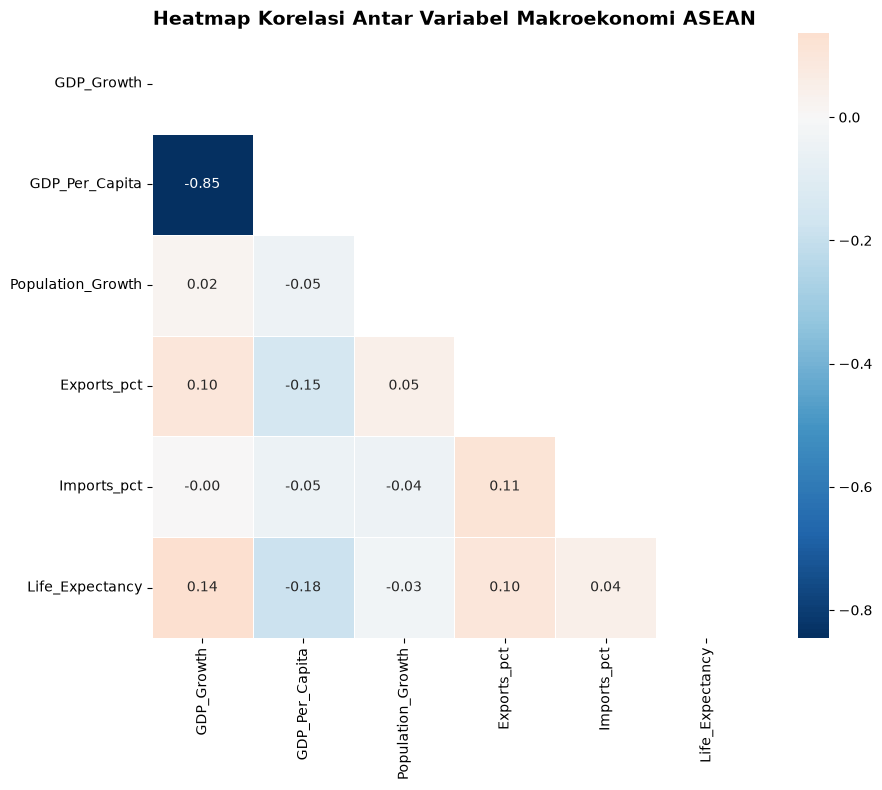

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv(r'c:\Users\Fauzi Rizky\Kelompok1-ML\data\processed\dataset_asean.csv')
fitur_asean_baru = ['GDP_Growth', 'GDP_Per_Capita', 'Population_Growth', 'Exports_pct', 'Imports_pct', 'Life_Expectancy']

# Memastikan kolom benar-benar ada sebelum dihitung korelasinya (Sesuai instruksi Poin 9)
fitur_tersedia = [col for col in fitur_asean_baru if col in df.columns]

corr = df[fitur_tersedia].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr, 
    mask=mask, 
    annot=True, 
    fmt='.2f', 
    cmap='RdBu_r', 
    center=0, 
    square=True, 
    linewidths=0.5
)

plt.title('Heatmap Korelasi Antar Variabel Makroekonomi ASEAN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

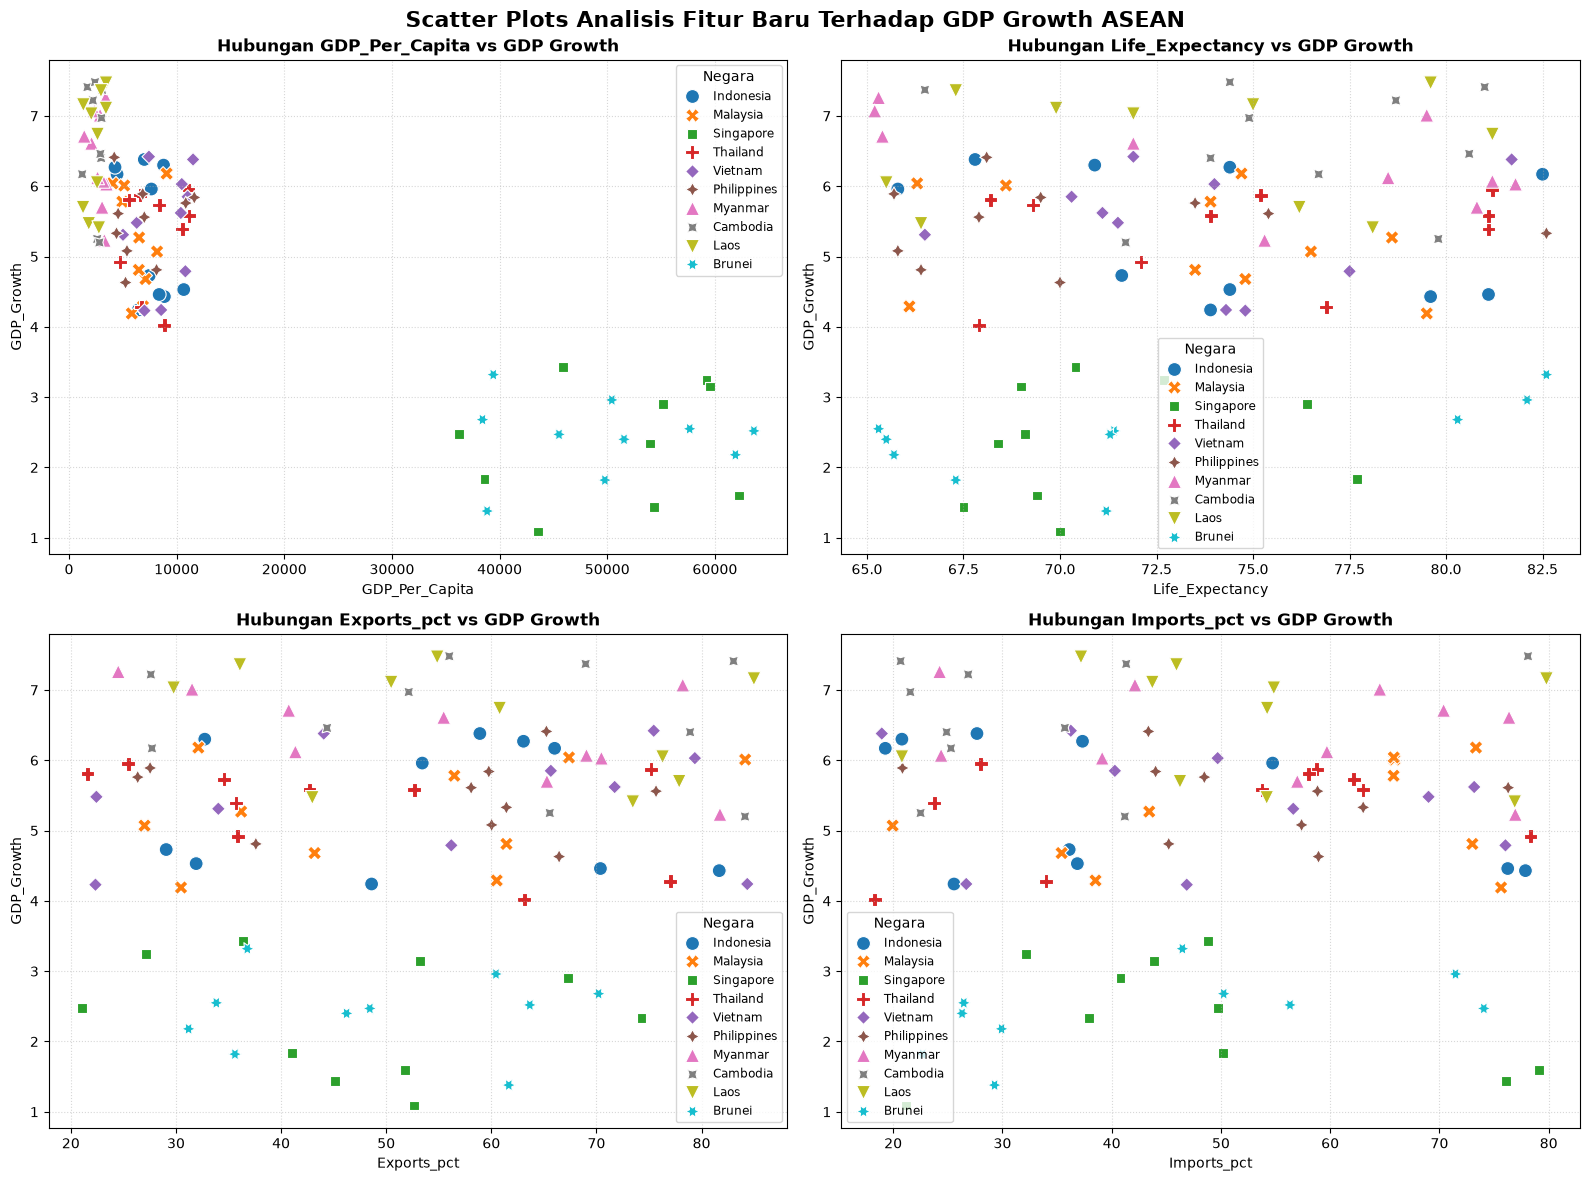

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'c:\Users\Fauzi Rizky\Kelompok1-ML\data\processed\dataset_asean.csv')

# Fitur yang akan diuji hubungannya dengan GDP_Growth
fitur_scatter = ['GDP_Per_Capita', 'Life_Expectancy', 'Exports_pct', 'Imports_pct']

# Membuat susunan grafik 2x2 agar rapi dan tidak memakan tempat
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, fitur in enumerate(fitur_scatter):
    if fitur in df.columns:
        sns.scatterplot(
            data=df, 
            x=fitur, 
            y='GDP_Growth', 
            hue='country', 
            style='country', 
            s=100, 
            ax=axes[i]
        )
        axes[i].set_title(f'Hubungan {fitur} vs GDP Growth', fontsize=12, fontweight='bold')
        axes[i].grid(True, linestyle=':', alpha=0.5)
        
        # Atur posisi legend agar rapi di setiap sub-plot
        axes[i].legend(title='Negara', loc='best', fontsize='small')

plt.suptitle('Scatter Plots Analisis Fitur Baru Terhadap GDP Growth ASEAN', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

C:\Users\Fauzi Rizky\AppData\Local\Temp\ipykernel_19364\3231961612.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='country', y='GDP_Growth', palette='Set3')


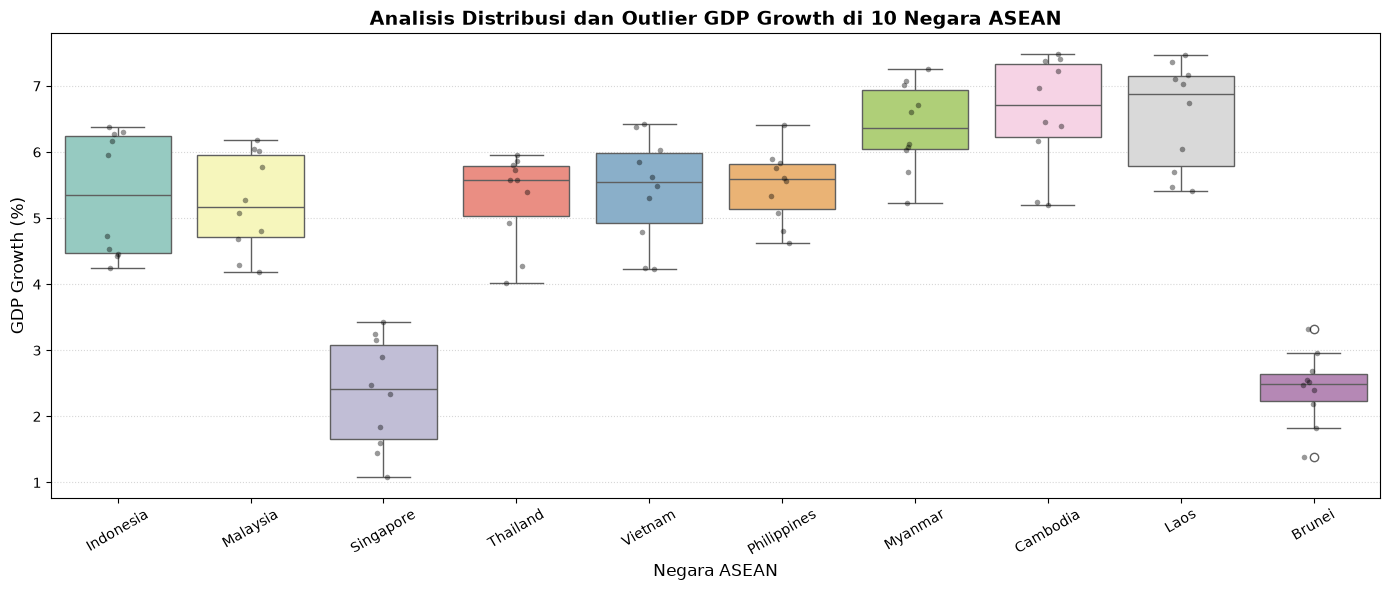

💡 [INSIGHT REVISI] Negara maju seperti Singapore & Brunei cenderung memiliki batas variasi pertumbuhan (box) yang lebih rendah (strik), sedangkan negara berkembang memiliki rentang box plot yang lebih tinggi.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'c:\Users\Fauzi Rizky\Kelompok1-ML\data\processed\dataset_asean.csv')

plt.figure(figsize=(14, 6))
# Membuat boxplot sebaran GDP Growth 10 negara
sns.boxplot(data=df, x='country', y='GDP_Growth', palette='Set3')
# Menimpa dengan stripplot agar titik data pencilan (outlier) terlihat jelas
sns.stripplot(data=df, x='country', y='GDP_Growth', color='black', alpha=0.4, size=4)

plt.title('Analisis Distribusi dan Outlier GDP Growth di 10 Negara ASEAN', fontsize=14, fontweight='bold')
plt.xlabel('Negara ASEAN', fontsize=12)
plt.ylabel('GDP Growth (%)', fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

print("💡 [INSIGHT REVISI] Negara maju seperti Singapore & Brunei cenderung memiliki batas variasi pertumbuhan (box) yang lebih rendah (strik), sedangkan negara berkembang memiliki rentang box plot yang lebih tinggi.")

In [7]:
%%writefile ../scripts/visualization.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_gdp_trend(df, country=None):
    """
    Tugas Poin 7: Menampilkan tren GDP Growth.
    """
    plt.figure(figsize=(12, 6))
    if country:
        df_filtered = df[df['country'].str.lower() == country.lower()]
        if df_filtered.empty:
            print(f"[⚠️ WARNING] Negara '{country}' tidak ditemukan.")
            return
        sns.lineplot(data=df_filtered, x='year', y='GDP_Growth', marker='o', linewidth=2.5, color='dodgerblue')
        plt.title(f'Tren Perkembangan GDP Growth - {country.title()}', fontsize=14, fontweight='bold')
    else:
        df_avg = df.groupby('year')['GDP_Growth'].mean().reset_index()
        sns.lineplot(data=df_avg, x='year', y='GDP_Growth', marker='s', linewidth=2.5, color='crimson')
        plt.title('Tren Rata-Rata GDP Growth Keseluruhan Negara ASEAN', fontsize=14, fontweight='bold')
        
    plt.xlabel('Tahun')
    plt.ylabel('GDP Growth (%)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    return plt.gcf()

def plot_country_comparison(df, country_list, metric='GDP_Growth'):
    """
    Tugas Poin 8: Fungsi baru untuk perbandingan multi-negara.
    """
    df_filtered = df[df['country'].isin(country_list)]
    if df_filtered.empty:
        print("[⚠️ WARNING] Tidak ada negara dari list yang cocok.")
        return
        
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=df_filtered, x='year', y=metric, hue='country', marker='o', linewidth=2.5, palette='tab10')
    plt.title(f'Analisis Perbandingan {metric.replace("_", " ")} Antar Negara ASEAN', fontsize=14, fontweight='bold')
    plt.xlabel('Tahun')
    plt.ylabel(metric.replace('_', ' '))
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(title='Negara', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    return plt.gcf()

def plot_correlation_heatmap(df):
    """
    Tugas Poin 9: Korelasi fitur ASEAN baru dengan pengecekan aman.
    """
    fitur_asean_baru = ['GDP_Growth', 'GDP_Per_Capita', 'Population_Growth', 'Exports_pct', 'Imports_pct', 'Life_Expectancy']
    fitur_test = [col for col in fitur_asean_baru if col in df.columns]
    
    if len(fitur_test) < 2:
        print("[⚠️ INFO] Fitur tidak mencukupi untuk korelasi.")
        return

    corr = df[fitur_test].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax)
    ax.set_title('Heatmap Korelasi Antar Variabel Makroekonomi ASEAN', fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

Overwriting ../scripts/visualization.py


Testing Poin 7 (Spesifik Negara):
Testing Poin 7 (Rata-rata Keseluruhan):
Testing Poin 8 (Perbandingan Multi-Negara):


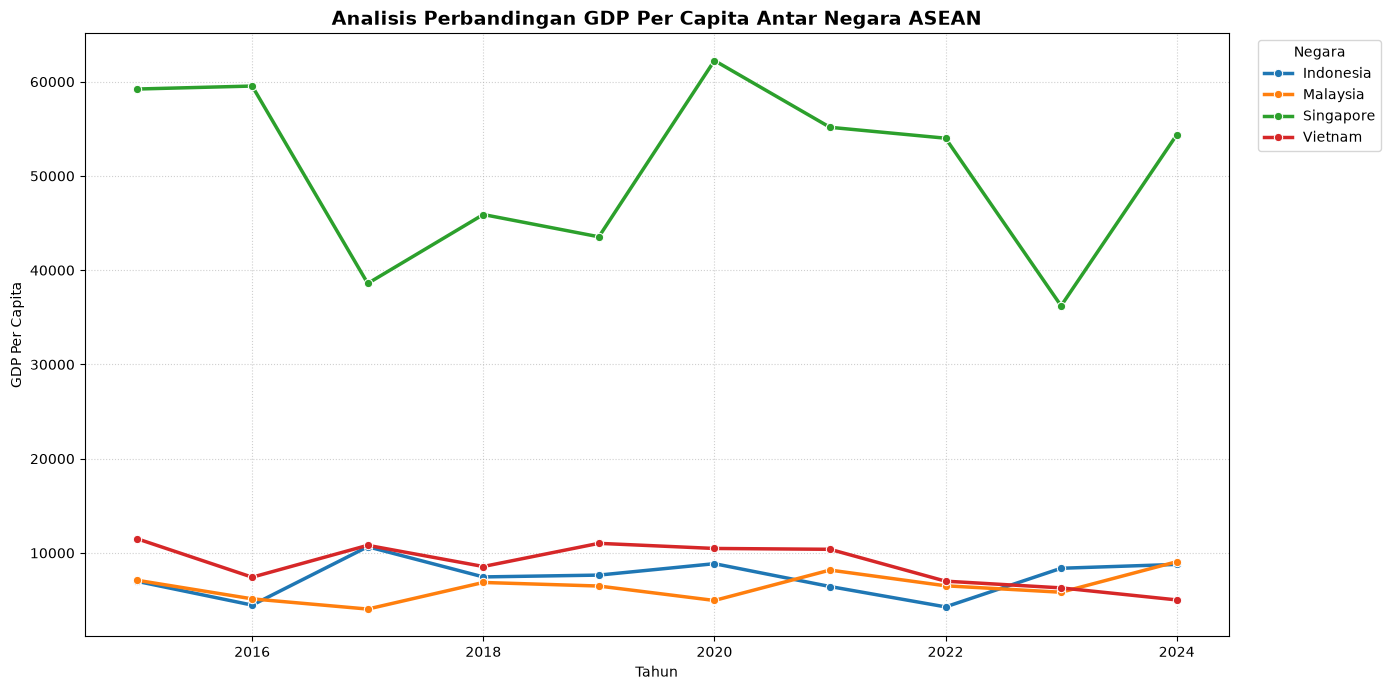

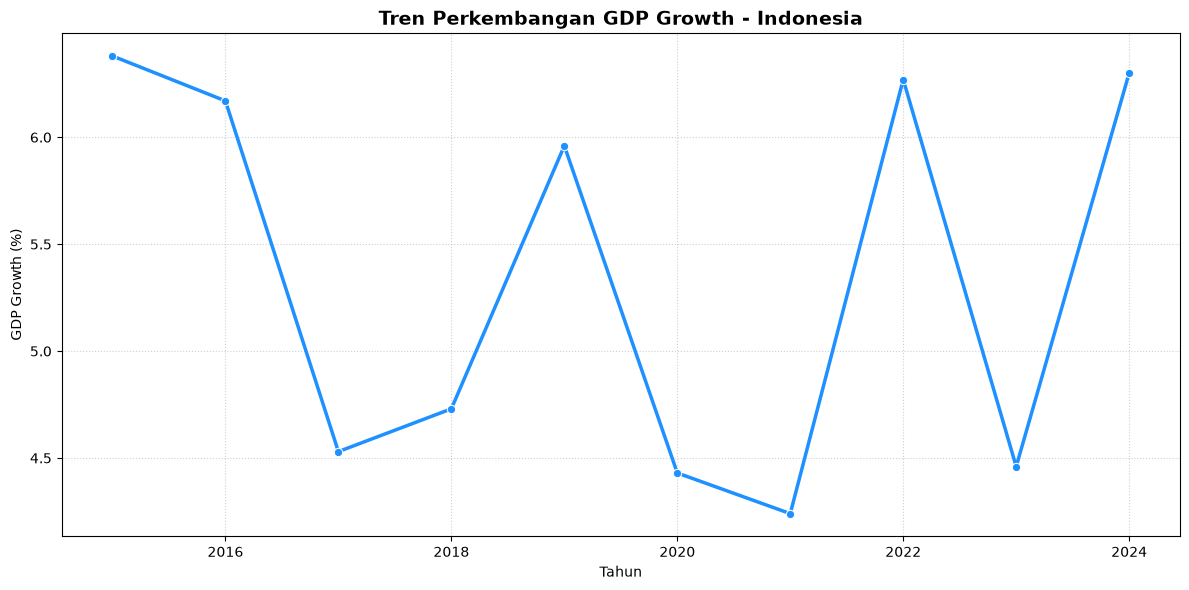

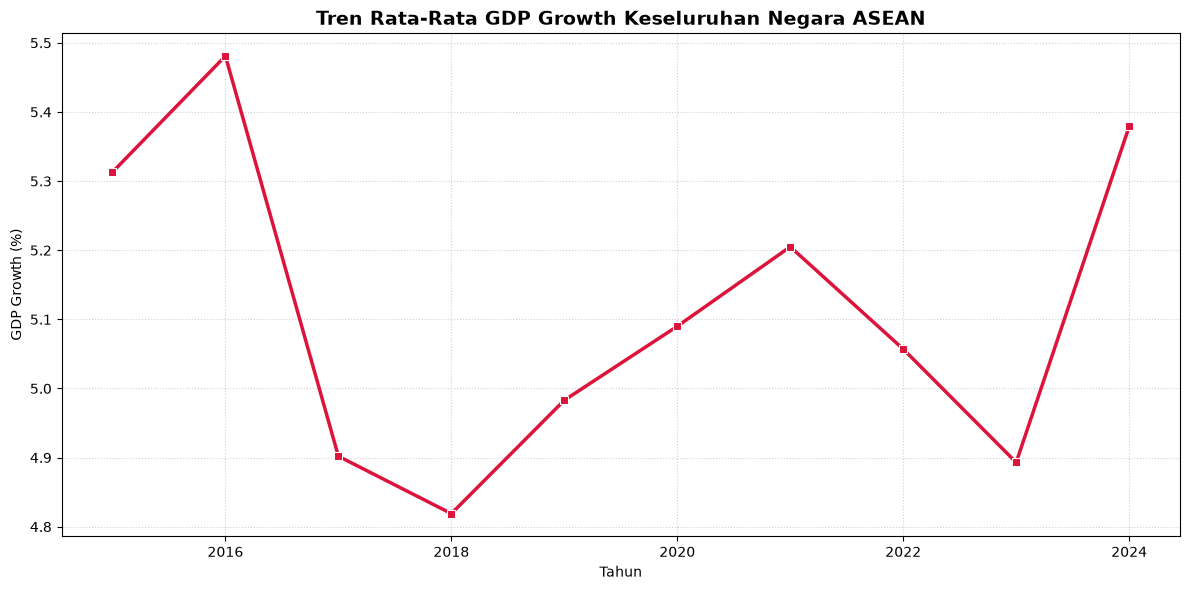

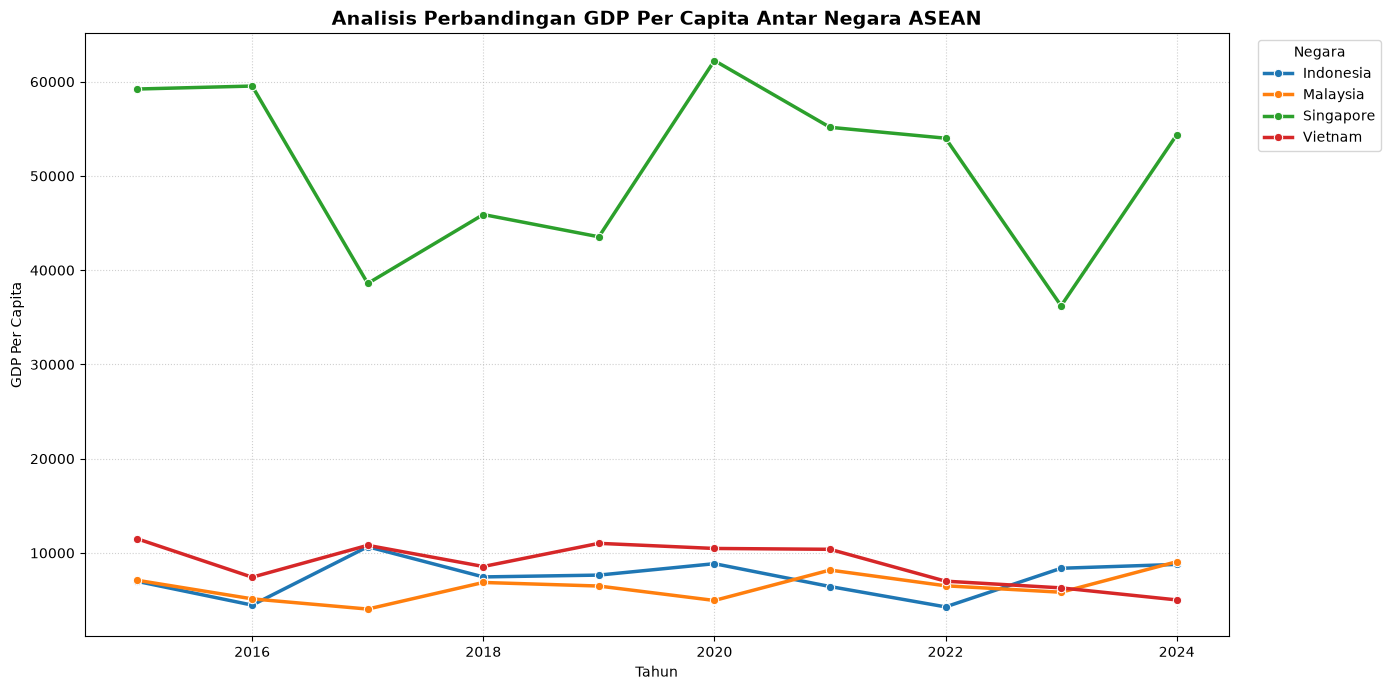

In [8]:
# Import fungsi yang baru saja kita tulis di skrip visualization.py
import sys
sys.path.append('../') # Naik ke folder utama proyek jika struktur folder Anda bercabang
from scripts.visualization import plot_gdp_trend, plot_country_comparison, plot_correlation_heatmap
import pandas as pd

# Load data pembuktian
df_test = pd.read_csv(r'c:\Users\Fauzi Rizky\Kelompok1-ML\data\processed\dataset_asean.csv')

# 1. Tes Tugas Poin 7 (Filter negara opsional)
print("Testing Poin 7 (Spesifik Negara):")
plot_gdp_trend(df_test, country='Indonesia')

print("Testing Poin 7 (Rata-rata Keseluruhan):")
plot_gdp_trend(df_test)

# 2. Tes Tugas Poin 8 (Multi-country comparison)
print("Testing Poin 8 (Perbandingan Multi-Negara):")
negara_pilihan = ['Indonesia', 'Singapore', 'Malaysia', 'Vietnam']
plot_country_comparison(df_test, country_list=negara_pilihan, metric='GDP_Per_Capita')

--- MEMULAI TES FUNGSI VISUALISASI REVISI ---

[TES POIN 7] Grafik Tren Satu Negara:

[TES POIN 8] Grafik Perbandingan Multi-Negara ASEAN:


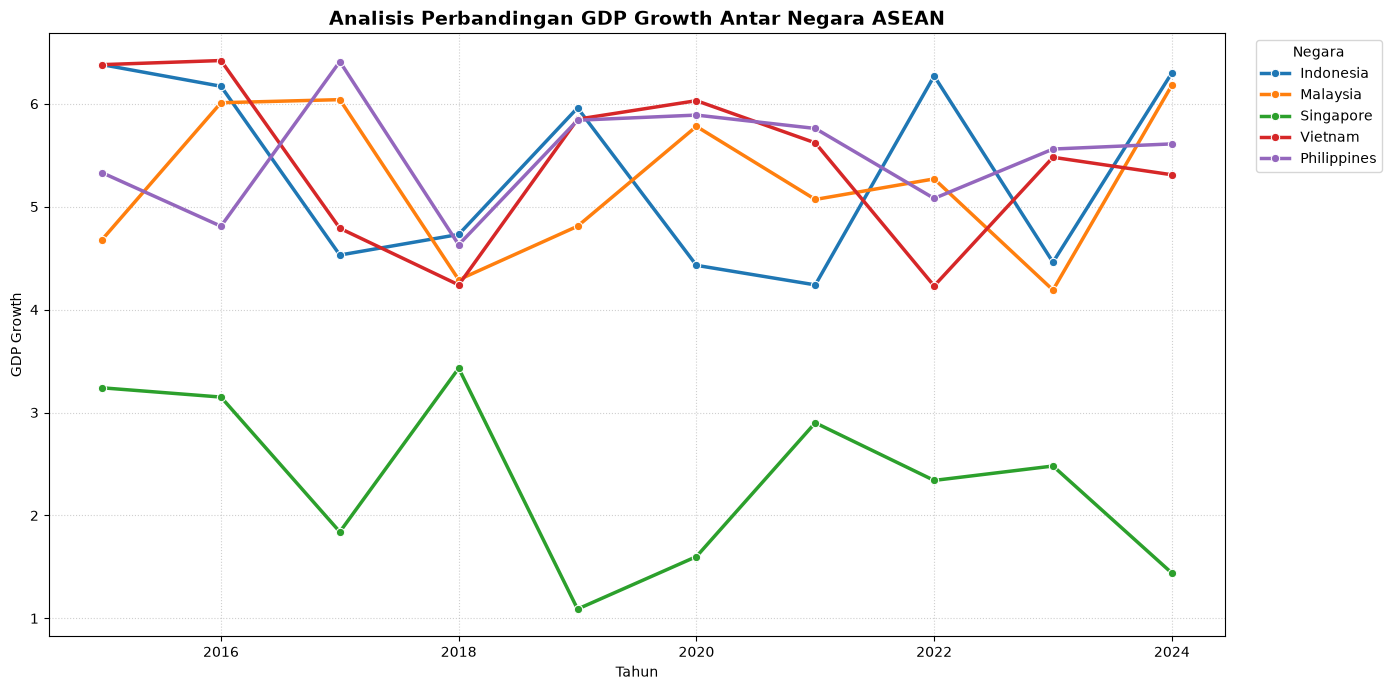

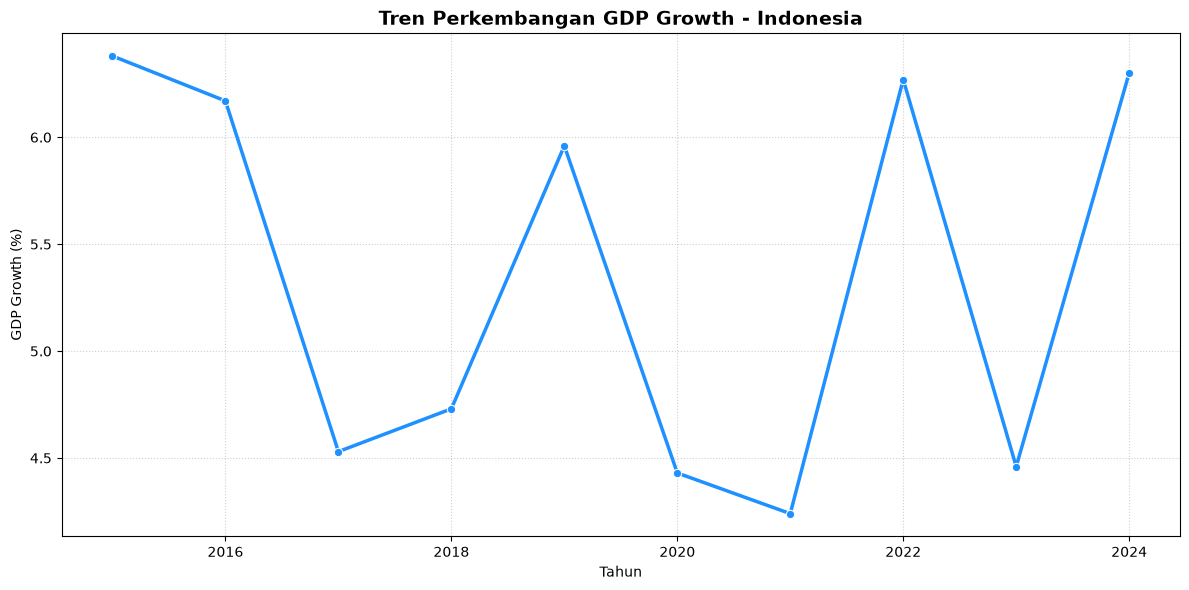

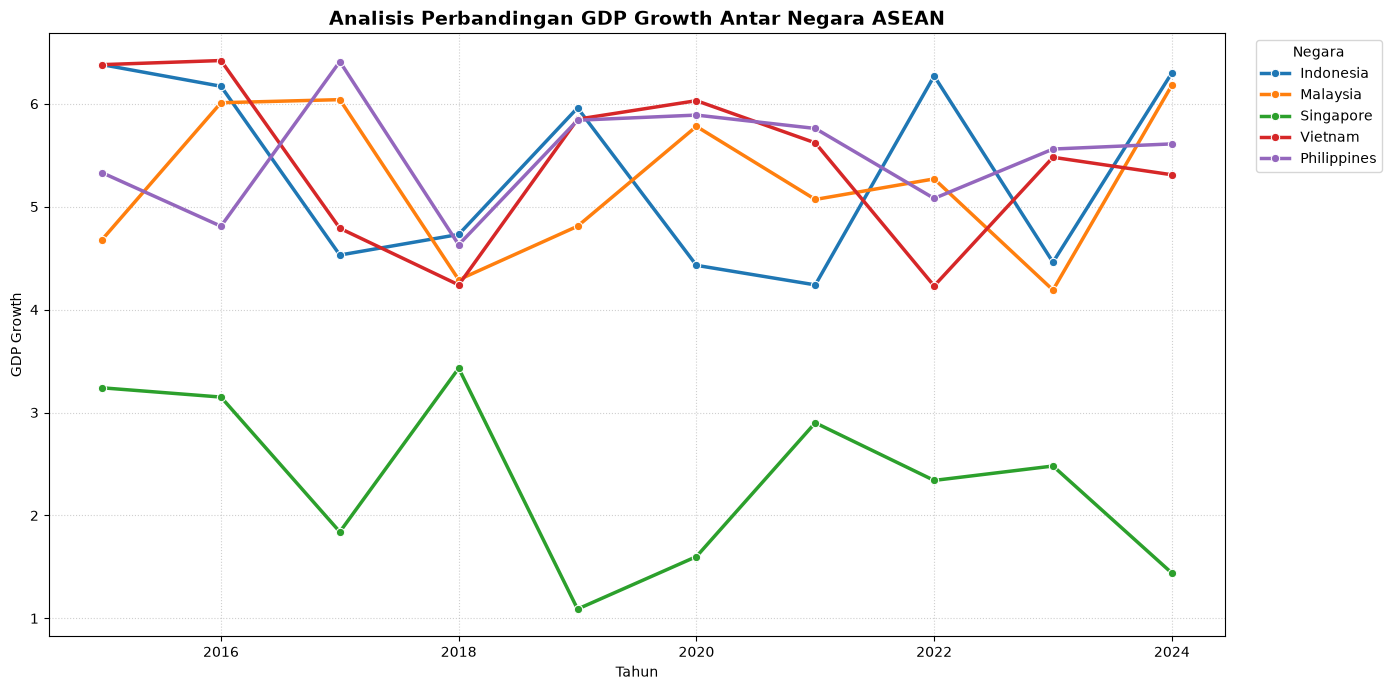

In [9]:
import sys
import os
import pandas as pd

# Memastikan Python mencari ke folder utama project kelompok Anda
sys.path.append(os.path.abspath(os.path.join('..')))

# Mengimpor ulang fungsi-fungsi visualisasi yang bersih dari Plotly
from scripts.visualization import plot_gdp_trend, plot_country_comparison, plot_correlation_heatmap

# Load data pembuktian 10 negara ASEAN
df_test = pd.read_csv(r'c:\Users\Fauzi Rizky\Kelompok1-ML\data\processed\dataset_asean.csv')

print("--- MEMULAI TES FUNGSI VISUALISASI REVISI ---")

# 1. Tes Fungsi Poin 7
print("\n[TES POIN 7] Grafik Tren Satu Negara:")
plot_gdp_trend(df_test, country='Indonesia')

# 2. Tes Fungsi Poin 8
print("\n[TES POIN 8] Grafik Perbandingan Multi-Negara ASEAN:")
negara_pilihan = ['Indonesia', 'Singapore', 'Malaysia', 'Vietnam', 'Philippines']
plot_country_comparison(df_test, country_list=negara_pilihan, metric='GDP_Growth')